---
draft: true

---

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [6]:
crime_df = pd.read_csv('crime.incidents.csv')

In [7]:
crime_df.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng
0,0101000020E610000034D87A0A89CB52C02834C6AA68F5...,1,0101000020110F0000252B547DE0EC5FC1822965612984...,33239012,1,1,2025-08-29 18:48:00+00,2025-08-29,14:48:00,14,2.025010e+11,1900 BLOCK Johnston St,300.0,Robbery No Firearm,-75.180239,39.917257,39.917257,-75.180239
1,0101000020E61000006085A41489CF52C010B29AEBCAF4...,2,0101000020110F00003AF38DECABF35FC1A250FBB47A83...,31111013,12,1,2025-06-29 10:10:00+00,2025-06-29,06:10:00,6,2.025121e+11,2500 BLOCK ISLAND AVE,600.0,Theft from Vehicle,-75.242742,39.912443,39.912443,-75.242742
2,0101000020E6100000483D5F41A7C952C010D2996F95F7...,3,0101000020110F00004C03D720AEE95FC14B4695FD9186...,29086214,3,2,2025-05-03 03:44:00+00,2025-05-02,23:44:00,23,2.025030e+11,1100 BLOCK S 4TH ST,300.0,Robbery No Firearm,-75.150833,39.934248,39.934248,-75.150833
3,0101000020E61000001C788C5D48C752C06028B3F01EFE...,4,0101000020110F00007F7FC043A7E55FC110D4D448D08D...,36767813,24,3,2025-12-20 01:52:00+00,2025-12-19,20:52:00,20,2.025241e+11,2900 BLOCK Memphis St,300.0,Robbery No Firearm,-75.113792,39.985319,39.985319,-75.113792
4,0101000020E61000007C8662EB0CC652C0F83367106E06...,5,0101000020110F00000AB1AD728FE35FC19ECF66340797...,32504813,2,2,2025-08-08 18:51:00+00,2025-08-08,14:51:00,14,2.025020e+11,6400 BLOCK RISING SUN AVE,600.0,Thefts,-75.094539,40.050234,40.050234,-75.094539


In [20]:
for hour in range(24):

    hour_data = crime_df[crime_df["hour"] == hour]

    counts = hour_data["text_general_code"].value_counts()

    most_common = counts.index[0]
    count = counts.values[0]

    print("Hour", hour, ":", most_common, "-", count)

#Big story lead up, what crime happens at what hour.

Hour 0 : Other Assaults - 665
Hour 1 : Other Assaults - 495
Hour 2 : Other Assaults - 357
Hour 3 : Other Assaults - 293
Hour 4 : Other Assaults - 190
Hour 5 : Motor Vehicle Theft - 204
Hour 6 : All Other Offenses - 201
Hour 7 : Motor Vehicle Theft - 621
Hour 8 : Thefts - 1110
Hour 9 : Thefts - 1419
Hour 10 : Thefts - 1583
Hour 11 : Thefts - 1783
Hour 12 : Thefts - 1875
Hour 13 : Thefts - 1725
Hour 14 : Thefts - 1465
Hour 15 : Thefts - 1605
Hour 16 : Thefts - 2219
Hour 17 : Thefts - 1974
Hour 18 : Thefts - 1767
Hour 19 : Thefts - 1448
Hour 20 : Thefts - 1234
Hour 21 : Other Assaults - 827
Hour 22 : All Other Offenses - 577
Hour 23 : Other Assaults - 606


In [22]:
crime_df["text_general_code"].value_counts().head(10)

#top 10 total amount of diff crime in 2025

text_general_code
Thefts                           24727
Other Assaults                   17881
All Other Offenses               10564
Motor Vehicle Theft               8918
Vandalism/Criminal Mischief       8278
Theft from Vehicle                6763
Fraud                             5864
Aggravated Assault No Firearm     3679
Burglary Residential              2075
Robbery No Firearm                1538
Name: count, dtype: int64

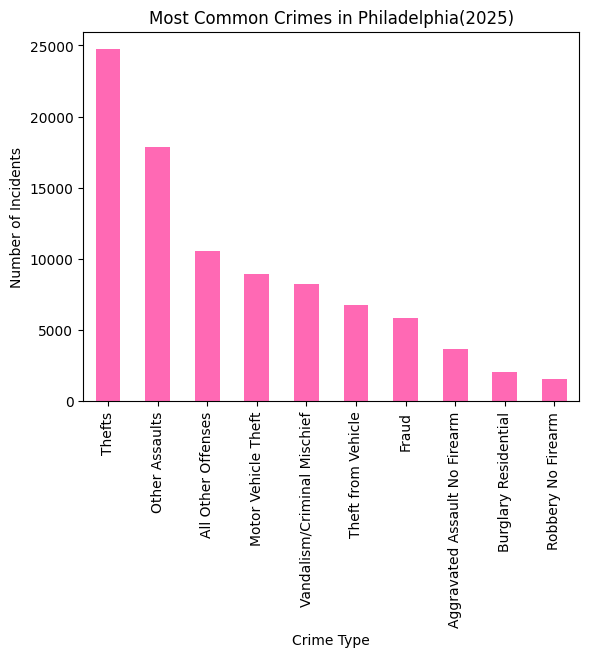

In [23]:
crime_df["text_general_code"].value_counts().head(10).plot(kind="bar", color="hotpink")

plt.title("Most Common Crimes in Philadelphia(2025)")
plt.xlabel("Crime Type")
plt.ylabel("Number of Incidents")

plt.show()

#visual ^

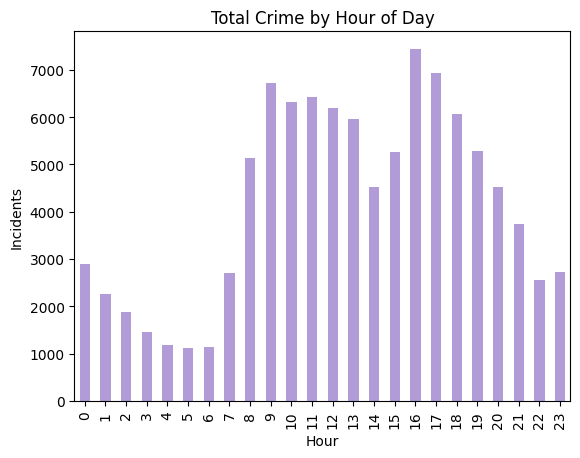

In [31]:
crime_df["hour"].value_counts().sort_index().plot(kind="bar", color="#B19CD8")

plt.title("Total Crime by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Incidents")

plt.show()

#Crime is not evenly distributed across the day. Certain hours experience significantly more incidents than others.

([<matplotlib.axis.XTick at 0x7fee82ac7bf0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

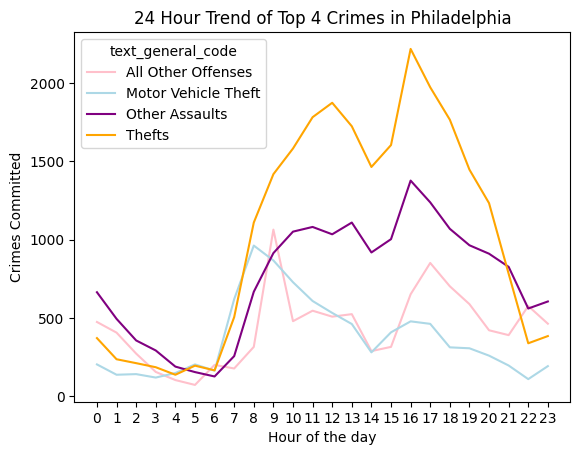

In [45]:
top_crimes = crime_df["text_general_code"].value_counts().head(4).index

df_top = crime_df[crime_df["text_general_code"].isin(top_crimes)]

df_top.groupby(["hour","text_general_code"]).size().unstack().plot(color=["pink", "lightblue", "purple", "orange"])
plt.title("24 Hour Trend of Top 4 Crimes in Philadelphia") 
plt.ylabel("Crimes Committed")
plt.xlabel("Hour of the day")
plt.xticks(range(24))

#shows the top 4 crimes and where they spike accross the day